<a href="https://colab.research.google.com/github/jspanchu/4961_hw/blob/main/hw3_q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

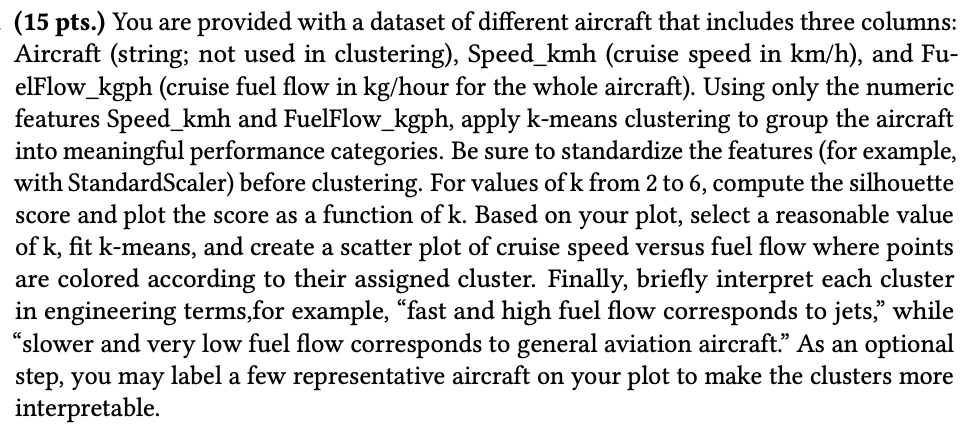

In [2]:
import pandas as pd
aircraft_performance = pd.read_csv("/content/work/aircraft_performance.csv")
print(aircraft_performance.columns)

Index(['Aircraft', 'Speed_kmh', 'FuelFlow_kgph'], dtype='object')


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Extract features
features = ['Speed_kmh', 'FuelFlow_kgph']
X = aircraft_performance[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
# Let's use 3 clusters representing typical performance tiers (e.g., Low, Medium, High)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
aircraft_performance['Cluster'] = kmeans.fit_predict(X_scaled)

# Display the clustered dataframe
display(aircraft_performance)

,Aircraft,Speed_kmh,FuelFlow_kgph,Cluster
0,Cessna_172,226,24,2
1,Cessna_182,260,30,2
2,Piper_PA28,215,22,2
3,Diamond_DA40,240,26,2
4,Cirrus_SR20,250,29,2
5,Cirrus_SR22,300,36,2
6,Beech_Bonanza,285,34,2
7,Mooney_M20,290,33,2
8,Pilatus_PC12,520,780,0
9,Beechcraft_KingAir_200,540,900,0


['2:0.64', '3:0.69', '4:0.79', '5:0.73', '6:0.74']


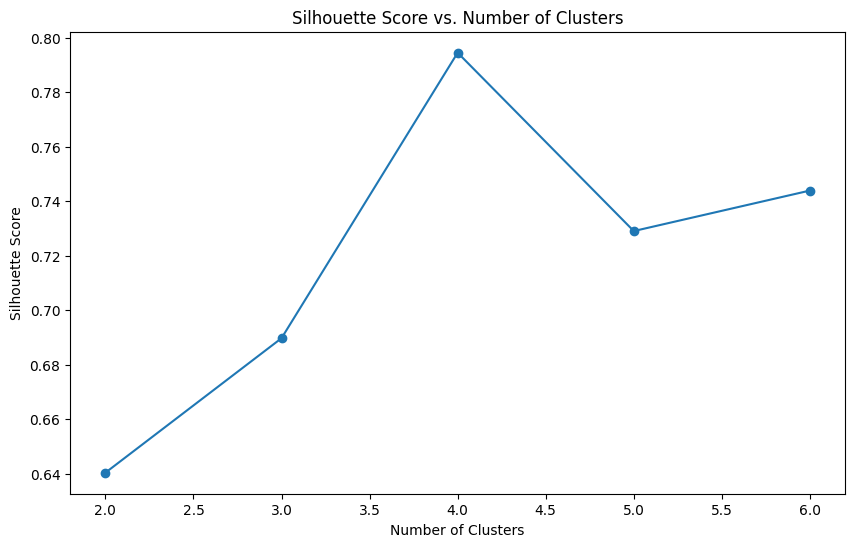

In [14]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,7):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  scores.append(silhouette_score(X_scaled, kmeans.fit_predict(X_scaled)))
print([f"{i+2}:{scores[i]:.2f}" for i, score in enumerate(scores)])
plt.figure(figsize=(10, 6))
plt.plot(range(2, 7), scores, marker='o', linestyle='-')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

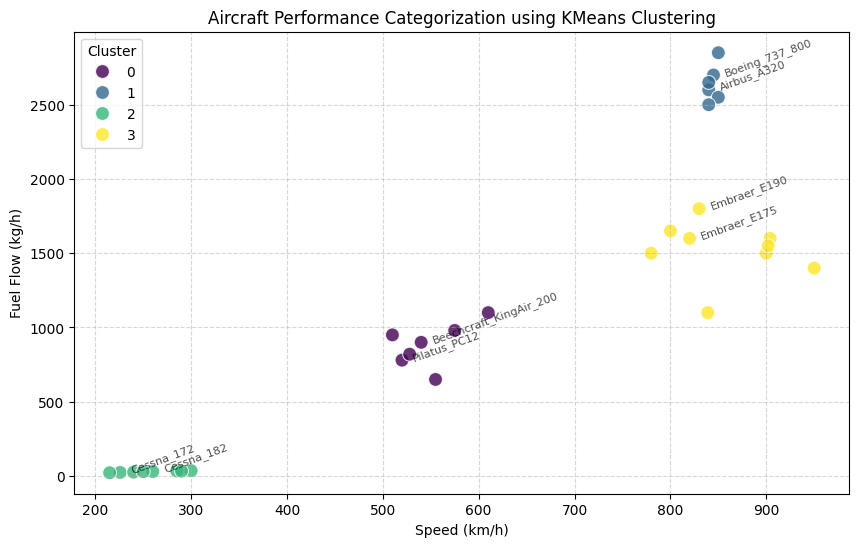

In [23]:
# Choose n_clusters=4 because it has highest average sillhouette score of 0.73
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
aircraft_performance['Cluster'] = kmeans.fit_predict(X_scaled)
# Visualize the resulting clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=aircraft_performance,
    x='Speed_kmh',
    y='FuelFlow_kgph',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)

# Only annotate upto 3 aircraft per cluster.
for cluster in aircraft_performance['Cluster'].unique():
    cluster_data = aircraft_performance[aircraft_performance['Cluster'] == cluster].head(2)
    for _, row in cluster_data.iterrows():
      plt.text(row['Speed_kmh'] + 10, row['FuelFlow_kgph'], row['Aircraft'], fontsize=8, alpha=0.7,rotation=20)

plt.title('Aircraft Performance Categorization using KMeans Clustering')
plt.xlabel('Speed (km/h)')
plt.ylabel('Fuel Flow (kg/h)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Interpretation of clusters

1. Cluster 2 (Green): Slower, single-engine props (Low speed, minimal fuel flow)

2. Cluster 0 (Violet): Twin-engine turboprops (Moderate speed, Moderate fuel flow)

3. Cluster 3 (Yellow): Business jets and light regional jets (High speed, moderate to high fuel flow)

4. Cluster 1 (Blue): Commercial airliners (High speed, high fuel flow)